# REHAB24 ExerciseTCN Training

This notebook trains an ExerciseTCN model for exercise recognition using the REHAB24 dataset.

It keeps:
- REHAB24 only
- Camera17 only
- cleaned subset: `mocap_erroneous == 0`, `extra_person_in_cam17 <= 1`
- `classREHABV2` representation: `33 landmarks -> 32 frames -> 338 features`

The model predicts one of 6 exercise classes using a Temporal Convolutional Network.

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [ ]:
EXERCISE_NAMES = {
    1: "Arm Abduction",
    2: "Arm VW",
    3: "Push-ups",
    4: "Leg Abduction",
    5: "Leg Lunge",
    6: "Squats",
}

TEST_SUBJECTS = [2, 8]
VAL_SUBJECTS = [3, 7]

BATCH_SIZE = 32
EPOCHS = 80
LR = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.50
PATIENCE = 10


DATA_DIR = Path("../artifacts/artifacts_rehab24_fullreps_F32")
OUT_DIR = Path("../artifacts/conditioned_tcn_Final")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("OUT_DIR:", OUT_DIR.resolve())
print("TEST_SUBJECTS:", TEST_SUBJECTS)
print("VAL_SUBJECTS:", VAL_SUBJECTS)

DATA_DIR: ..\artifacts\artifacts_rehab24_fullreps_F32
OUT_DIR: C:\Users\nadaf\Desktop\RehabClass\classRehabFinal\artifacts\conditioned_tcn_Final
TEST_SUBJECTS: [2, 8]
VAL_SUBJECTS: [3, 7]


In [3]:
X_pose = np.load(DATA_DIR / "X_pose.npy")
X_angles = np.load(DATA_DIR / "X_angles.npy")
y = np.load(DATA_DIR / "y.npy").astype(np.int64)
index_df = pd.read_csv(DATA_DIR / "index_clean.csv")

mask_clean = (
    (index_df["mocap_erroneous"].astype(int) == 0) &
    (index_df["extra_person_in_cam17"].astype(int) <= 1)
)

X_pose = X_pose[mask_clean.to_numpy()]
X_angles = X_angles[mask_clean.to_numpy()]
y = y[mask_clean.to_numpy()]
index_df = index_df.loc[mask_clean].reset_index(drop=True)

X_pose_flat = X_pose.reshape(X_pose.shape[0], X_pose.shape[1], -1)
X_all = np.concatenate([X_pose_flat, X_angles], axis=-1).astype(np.float32)

test_mask = index_df["person_id"].isin(TEST_SUBJECTS).to_numpy()
val_mask = index_df["person_id"].isin(VAL_SUBJECTS).to_numpy()
train_mask = ~(test_mask | val_mask)

X_train = X_all[train_mask]
X_val = X_all[val_mask]
X_test = X_all[test_mask]

y_train = y[train_mask]
y_val = y[val_mask]
y_test = y[test_mask]

idx_train = index_df.loc[train_mask].reset_index(drop=True)
idx_val = index_df.loc[val_mask].reset_index(drop=True)
idx_test = index_df.loc[test_mask].reset_index(drop=True)

train_subjects = sorted(idx_train["person_id"].unique().tolist())

print("Clean subset:", len(index_df))
print("Train subjects:", train_subjects)
print("Val subjects:", sorted(idx_val["person_id"].unique().tolist()))
print("Test subjects:", sorted(idx_test["person_id"].unique().tolist()))
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

print("\nValidation per exercise/class:")
print(idx_val.groupby(["exercise_id", "correctness"]).size().unstack(fill_value=0).reindex(range(1,7), fill_value=0))
print("\nTest per exercise/class:")
print(idx_test.groupby(["exercise_id", "correctness"]).size().unstack(fill_value=0).reindex(range(1,7), fill_value=0))

train_mean = X_train.reshape(-1, X_train.shape[-1]).mean(axis=0, keepdims=True)
train_std = X_train.reshape(-1, X_train.shape[-1]).std(axis=0, keepdims=True)
train_std = np.maximum(train_std, 1e-6)

def standardize(X, mean, std):
    return ((X - mean) / std).astype(np.float32)

X_train = standardize(X_train, train_mean, train_std)
X_val = standardize(X_val, train_mean, train_std)
X_test = standardize(X_test, train_mean, train_std)

Clean subset: 793
Train subjects: [1, 4, 5, 6, 9, 10]
Val subjects: [3, 7]
Test subjects: [2, 8]
Train: (430, 32, 338) Val: (182, 32, 338) Test: (181, 32, 338)

Validation per exercise/class:
correctness   0   1
exercise_id        
1            13  18
2            19  17
3             7   4
4            10  27
5            24   8
6            19  16

Test per exercise/class:
correctness   0   1
exercise_id        
1            15  20
2            28   8
3             4   9
4            17  23
5            15  15
6             3  24


In [4]:
class ExerciseDataset(Dataset):
    def __init__(self, X, exercise_ids, augment=False):
        self.X = np.asarray(X, dtype=np.float32)
        self.exercise_ids = np.asarray(exercise_ids, dtype=np.int64)
        self.augment = bool(augment)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        x = torch.tensor(x.transpose(1, 0), dtype=torch.float32)

        # exercise_id is 1-6, but CrossEntropy needs 0-5
        y_ex = torch.tensor(int(self.exercise_ids[idx] - 1), dtype=torch.long)

        return x, y_ex

train_ex = idx_train["exercise_id"].to_numpy(dtype=np.int64)
val_ex = idx_val["exercise_id"].to_numpy(dtype=np.int64)
test_ex = idx_test["exercise_id"].to_numpy(dtype=np.int64)

ex_train_ds = ExerciseDataset(X_train, train_ex, augment=False)
ex_val_ds = ExerciseDataset(X_val, val_ex, augment=False)
ex_test_ds = ExerciseDataset(X_test, test_ex, augment=False)

ex_train_loader = DataLoader(ex_train_ds, batch_size=BATCH_SIZE, shuffle=True)
ex_val_loader = DataLoader(ex_val_ds, batch_size=BATCH_SIZE, shuffle=False)
ex_test_loader = DataLoader(ex_test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Train groups:")
print(idx_train.groupby(["exercise_id", "correctness"]).size().unstack(fill_value=0).reindex(range(1,7), fill_value=0))

Train groups:
correctness   0   1
exercise_id        
1            41  43
2            44  46
3            21  20
4            22  27
5            35  37
6            29  65


In [5]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x if self.chomp_size == 0 else x[:, :, :-self.chomp_size]


class ResidualTCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, dropout=0.5):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()
        self.out_relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.net(x)
        res = self.downsample(x)
        return self.out_relu(out + res)


class ExerciseTCN(nn.Module):
    def __init__(self, input_dim, num_exercises=6, dropout=0.5):
        super().__init__()
        self.backbone = nn.Sequential(
            ResidualTCNBlock(input_dim, 64, kernel_size=3, dilation=1, dropout=dropout),
            ResidualTCNBlock(64, 64, kernel_size=3, dilation=2, dropout=dropout),
            ResidualTCNBlock(64, 96, kernel_size=3, dilation=4, dropout=dropout),
            ResidualTCNBlock(96, 96, kernel_size=3, dilation=8, dropout=dropout),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(96, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, num_exercises),
        )

    def forward(self, x):
        feats = self.backbone(x)
        pooled = self.pool(feats)
        logits = self.head(pooled)
        return logits

input_dim = X_train.shape[-1]
print("input_dim:", input_dim)

input_dim: 338


In [6]:
exercise_model = ExerciseTCN(
    input_dim=input_dim,
    num_exercises=6,
    dropout=DROPOUT,
).to(DEVICE)

ex_optimizer = torch.optim.AdamW(
    exercise_model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

ex_criterion = nn.CrossEntropyLoss()

best_ex_state = None
best_ex_val_acc = -1
patience_left = PATIENCE

for epoch in range(1, EPOCHS + 1):
    exercise_model.train()
    train_loss_sum = 0
    train_n = 0

    for x, y_ex in ex_train_loader:
        x = x.to(DEVICE)
        y_ex = y_ex.to(DEVICE)

        ex_optimizer.zero_grad()
        logits = exercise_model(x)
        loss = ex_criterion(logits, y_ex)
        loss.backward()
        ex_optimizer.step()

        train_loss_sum += loss.item() * len(y_ex)
        train_n += len(y_ex)

    train_loss = train_loss_sum / train_n

    exercise_model.eval()
    all_true = []
    all_pred = []

    with torch.no_grad():
        for x, y_ex in ex_val_loader:
            x = x.to(DEVICE)
            y_ex = y_ex.to(DEVICE)

            logits = exercise_model(x)
            pred = torch.argmax(logits, dim=1)

            all_true.extend(y_ex.cpu().numpy())
            all_pred.extend(pred.cpu().numpy())

    val_acc = accuracy_score(all_true, all_pred)

    print(f"epoch {epoch:02d} | train_loss={train_loss:.4f} | val_ex_acc={val_acc:.4f}")

    if val_acc > best_ex_val_acc:
        best_ex_val_acc = val_acc
        best_ex_state = {k: v.detach().cpu().clone() for k, v in exercise_model.state_dict().items()}
        patience_left = PATIENCE
    else:
        patience_left -= 1
        if patience_left <= 0:
            print("Early stopping.")
            break

exercise_model.load_state_dict(best_ex_state)
print("Best exercise validation accuracy:", best_ex_val_acc)

epoch 01 | train_loss=1.5547 | val_ex_acc=0.5659
epoch 02 | train_loss=0.9642 | val_ex_acc=0.7033
epoch 03 | train_loss=0.5636 | val_ex_acc=0.7857
epoch 04 | train_loss=0.3466 | val_ex_acc=0.8516
epoch 05 | train_loss=0.2375 | val_ex_acc=0.9890
epoch 06 | train_loss=0.1618 | val_ex_acc=0.9725
epoch 07 | train_loss=0.0986 | val_ex_acc=0.9890
epoch 08 | train_loss=0.0592 | val_ex_acc=0.9890
epoch 09 | train_loss=0.0613 | val_ex_acc=0.9451
epoch 10 | train_loss=0.0738 | val_ex_acc=1.0000
epoch 11 | train_loss=0.0300 | val_ex_acc=0.9835
epoch 12 | train_loss=0.0315 | val_ex_acc=0.9945
epoch 13 | train_loss=0.0210 | val_ex_acc=1.0000
epoch 14 | train_loss=0.0235 | val_ex_acc=1.0000
epoch 15 | train_loss=0.0244 | val_ex_acc=1.0000
epoch 16 | train_loss=0.0552 | val_ex_acc=0.9670
epoch 17 | train_loss=0.0344 | val_ex_acc=0.9780
epoch 18 | train_loss=0.0175 | val_ex_acc=0.9780
epoch 19 | train_loss=0.0113 | val_ex_acc=0.9780
epoch 20 | train_loss=0.0139 | val_ex_acc=0.9780
Early stopping.
Best

In [7]:
exercise_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in ex_test_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits = exercise_model(x)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average="weighted")

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Weighted F1: {test_f1:.4f}")

Test Accuracy: 0.9724
Test Weighted F1: 0.9717


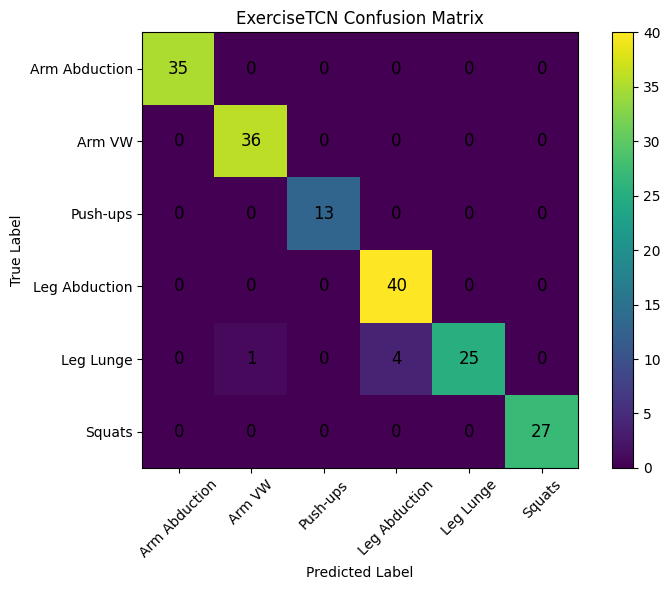

In [8]:
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

class_names = list(EXERCISE_NAMES.values())

plt.figure(figsize=(8, 6))

plt.imshow(cm, interpolation="nearest")
plt.title("ExerciseTCN Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=12
        )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")

plt.tight_layout()
plt.show()

In [10]:
exercise_ckpt_path = OUT_DIR / "best_exercise_recognition_tcn.pt"

torch.save(
    {
        "model_state_dict": exercise_model.state_dict(),
        "train_mean": train_mean.astype(np.float32),
        "train_std": train_std.astype(np.float32),
        "input_dim": int(input_dim),
        "exercise_names": EXERCISE_NAMES,
        "test_subjects": TEST_SUBJECTS,
        "val_subjects": VAL_SUBJECTS,
    },
    exercise_ckpt_path,
)

print("Saved exercise recognition model:", exercise_ckpt_path.resolve())

Saved exercise recognition model: C:\Users\nadaf\Desktop\RehabClass\classRehabFinal\artifacts\conditioned_tcn_Final\best_exercise_recognition_tcn.pt
